<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/nprivaul/fractionalpdes/blob/master/front_propagations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

This code solves the 1D time-fractional F-KPP equation 

$$\partial_t^\alpha u=-(-\Delta u)^{\gamma/2}-\lambda u+\lambda (p_0+p_1 u+\cdots +p_N u^N)$$

on $\mathbb{R}$ with initial condition $f$ and several time points $T=[t_1,\ldots ,t_n]$, $\lambda>0$, $p_k\in [0,1]$, and $p_0+ \cdots +p_N=1$, with $\gamma = 2$ and $\alpha = 0.5,1$.

In [1]:
import math
import matplotlib.pyplot as plt
from scipy.stats import expon,uniform,norm
import numpy as np
import time

plt.rcParams.update({
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 16,
    "legend.title_fontsize": 14,
    "xtick.major.pad": 8,        # Increase distance between x-axis and tick labels (default ~4)
    "figure.titlesize": 24,
    "axes.xmargin": 0,      # Equivalent to ax.margins(x=0)
    "figure.autolayout": True,  # Equivalent to plt.tight_layout()
})

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Sun Mar 15 01:18:21 2026

@author: gerar
"""

#=============================================================================
#MC ALGORITHM
#=============================================================================
def f(x,d): 
    """
    Initial condition - a function from R^d to [0,1]
    x=[x[1],...,x[d]] is an array if d>1; if d=1, x must be a float
    """
    if d==1:
        if x>=0:
            return 1
        else:
            return 0
    else:
        # For 2D/3D, use radially symmetric initial condition
        r_squared = sum(x_i**2 for x_i in x)
        return 0.5 + np.arctan(1000 * (1 - np.sqrt(r_squared))) / np.pi
    
def subordinator_rv(alpha):
    """
    This simulates S(1), where (S(t))_T is an \alpha-stable subordinator (Chambers, Mallows, Stuck (1976))
    alpha is a number in (0,1]
    """
    if alpha==1:
        return 1
    else:
        theta=math.pi*uniform.rvs()
        w=expon.rvs()
        aux1=(math.sin((1-alpha)*theta)/w)**((1-alpha)/alpha)
        aux2=math.sin(alpha*theta)/math.sin(theta)**(1/alpha)
        return aux1*aux2
    
def stable_rv(gamma,d,t):
    """
    This simulates X(t), where (X(t))_t is a d-dimensional symmetric gamma-stable process
    gamma is a number in (0,2], d is a natural number, t geq 0
    If d==1, the output is a float; if d>1, it is an array 
    """
    if d==1:
        return norm.rvs()*(2*subordinator_rv(gamma/2))**(1/2)*t**(1/gamma)  #Scaling property
    else:
       aux1=norm.rvs(size=d)
       aux2=subordinator_rv(gamma/2)
       return [aux1[i]*(2*aux2)**(1/2)*t**(1/gamma) for i in range(d)]

def discrete_rv(p):
    """
    This simulates a random variable on {0,1,..., N}, N>1, according to law [p_0,p_1,...,p_N]
    p_k is a number in [0,1] and p_0+p_1+...+p_N=1
    """
    aux=0
    u=uniform.rvs()
    for i in range(len(p)):
        if u<aux+p[i]:
            return i
        else:
            aux=aux+p[i]
    
def branching(alpha,gamma,lam,p,d,x,T):
    """
    This simulates the random variable V=prod_{k in mathcal{N}_t^\alpha}f(x+Y_k^\alpha(t))
    alpha,gam,lam,p,d are as in the section "PARAMETERS"
    x=[x[1],...,x[d]] is an array representing a point, T is a positive number representing time
    """
    s1=subordinator_rv(alpha)
    tau=expon.rvs()/lam                             #Exponential lifetime 
    sigma=s1*tau**(1/alpha)                         #Mittag Leffler lifetime
    if sigma>T:                                     #No branching case
        et=(T/s1)**alpha                            #Inverse stable subordinator law
        dx=stable_rv(gamma,d,et)                    #Spatial displacement
        if d==1:                                    #Dimension one case
            Y=x+dx                                  #Position at branching time
            return f(Y,d)
        else:                                       #Dimension greater than one
            Y=[x[i]+dx[i] for i in range(d)]
            return f(Y,d)
    else:                                           #Branching case
        branches=discrete_rv(p)                     #Number of branches
        aux=1
        dx=stable_rv(gamma,d,tau)                   
        if d==1:
            Y=x+dx
            for i in range(branches):
                aux=aux*branching(alpha,gamma,lam,p,d,Y,T-sigma)    #Recursion
            return aux 
        else:
            Y=[x[i]+dx[i] for i in range(d)]
            for i in range(branches):
                aux=aux*branching(alpha,gamma,lam,p,d,Y,T-sigma) 
            return aux
            
def mc_kpp_sol(alpha,gamma,lam,p,d,x,T,n_iter):           
    """
    This is the Monte Carlo estimator of the solution at (x,T)
    alpha,gam,lam,p,d are as in the section "Parameters"
    n_iter is the sample size
    """       
    aux=0
    for i in range(n_iter):
        aux=aux+branching(alpha,gamma,lam,p,d,x,T)
    return aux/n_iter               #MC estimator

#==============================================================================
#PARAMETERS
#==============================================================================
alpha=0.5   #time-fractional order \alpha - a number in (0,1]
gamma=2     #space-fractional order gamma - a number in (0,2]
lam=1.0     #\lambda - a strictly positive constant
p=[0,0,1]   #probability density [p_0,p_1,...,p_N] corresponding to the polynomial non-linearity - it satisfies p_k in[0,1] and p_0+p_1+...+p_N=1
d=1         #dimension - a natural number
T=4         #maximum time - a positive number
nt=4        #number of points in time discretization- a natural number
n_iter=1000 #sample size for Monte Carlo estimator - a natural number (reduced for speed)
a=-10              #[a,b] is interval of simulation - a<b, a,b are any reals
b=15
nx=101               #number of points in [a,b] - a natural number

#==============================================================================
#SIMULATION OF FRONT PROPAGATION
#==============================================================================
#Discretization
t=[(i+1)*T/nt for i in range(nt)]               #time discretization
x=[a+i*(b-a)/(nx-1) for i in range(nx)]         #space discretization (it must be consistent with dimension d)
y=[[0 for i in range(nx)] for i in range(nt)]   #array with simulations y[i] is the mc solution at time t[i] on [a,b]

start = time.time()

#MC simulation
#for i in range(nt):
#    for j in range(nx):
#        y[i][j]=mc_kpp_sol(alpha,gamma,lam,p,d,x[j],t[i],n_iter)
#        print(f"Progress: {j+1}/{nx} - {i+1}/{nt}")
from multiprocessing import Pool, cpu_count

def worker(idx):
    i, j = idx
    return i, j, mc_kpp_sol(alpha, gamma, lam, p, d, x[j], t[i], n_iter)

if __name__ == "__main__":

    y = np.zeros((nt, nx))

    tasks = [(i, j) for i in range(nt) for j in range(nx)]

    print(f"Using {cpu_count()} CPU cores for {nt*nx} evaluations...")

    with Pool(cpu_count()) as pool:
        for k, (i, j, val) in enumerate(pool.imap(worker, tasks), 1):
            y[i, j] = val
            print(f"Progress: {k}/{nt*nx} (i={i}, j={j})")

    y = np.array(y)
    


Using 8 CPU cores for 404 evaluations...
Progress: 1/404 (i=0, j=0)
Progress: 2/404 (i=0, j=1)
Progress: 3/404 (i=0, j=2)
Progress: 4/404 (i=0, j=3)
Progress: 5/404 (i=0, j=4)
Progress: 6/404 (i=0, j=5)
Progress: 7/404 (i=0, j=6)
Progress: 8/404 (i=0, j=7)
Progress: 9/404 (i=0, j=8)
Progress: 10/404 (i=0, j=9)
Progress: 11/404 (i=0, j=10)
Progress: 12/404 (i=0, j=11)
Progress: 13/404 (i=0, j=12)
Progress: 14/404 (i=0, j=13)
Progress: 15/404 (i=0, j=14)
Progress: 16/404 (i=0, j=15)
Progress: 17/404 (i=0, j=16)
Progress: 18/404 (i=0, j=17)
Progress: 19/404 (i=0, j=18)
Progress: 20/404 (i=0, j=19)
Progress: 21/404 (i=0, j=20)
Progress: 22/404 (i=0, j=21)
Progress: 23/404 (i=0, j=22)
Progress: 24/404 (i=0, j=23)
Progress: 25/404 (i=0, j=24)
Progress: 26/404 (i=0, j=25)
Progress: 27/404 (i=0, j=26)
Progress: 28/404 (i=0, j=27)
Progress: 29/404 (i=0, j=28)
Progress: 30/404 (i=0, j=29)
Progress: 31/404 (i=0, j=30)
Progress: 32/404 (i=0, j=31)
Progress: 33/404 (i=0, j=32)
Progress: 34/404 (i=0

Progress: 279/404 (i=2, j=76)
Progress: 280/404 (i=2, j=77)
Progress: 281/404 (i=2, j=78)
Progress: 282/404 (i=2, j=79)
Progress: 283/404 (i=2, j=80)
Progress: 284/404 (i=2, j=81)
Progress: 285/404 (i=2, j=82)
Progress: 286/404 (i=2, j=83)
Progress: 287/404 (i=2, j=84)
Progress: 288/404 (i=2, j=85)
Progress: 289/404 (i=2, j=86)
Progress: 290/404 (i=2, j=87)
Progress: 291/404 (i=2, j=88)
Progress: 292/404 (i=2, j=89)
Progress: 293/404 (i=2, j=90)
Progress: 294/404 (i=2, j=91)
Progress: 295/404 (i=2, j=92)
Progress: 296/404 (i=2, j=93)
Progress: 297/404 (i=2, j=94)
Progress: 298/404 (i=2, j=95)
Progress: 299/404 (i=2, j=96)
Progress: 300/404 (i=2, j=97)
Progress: 301/404 (i=2, j=98)
Progress: 302/404 (i=2, j=99)
Progress: 303/404 (i=2, j=100)
Progress: 304/404 (i=3, j=0)
Progress: 305/404 (i=3, j=1)
Progress: 306/404 (i=3, j=2)
Progress: 307/404 (i=3, j=3)
Progress: 308/404 (i=3, j=4)
Progress: 309/404 (i=3, j=5)
Progress: 310/404 (i=3, j=6)
Progress: 311/404 (i=3, j=7)
Progress: 312/404

812.8741071224213


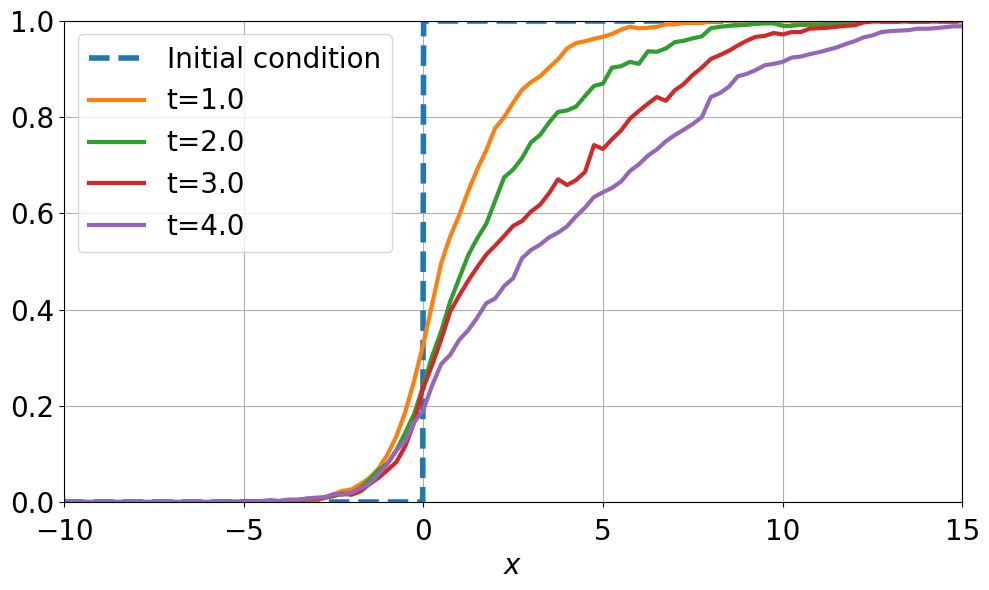

In [3]:
#Initial condition
x_ic=[a+i*(b-a)/(10*nx-1) for i in range(10*nx)]         #space discretization (it must be consistent with dimension d)
initial_condition = [f(x_ic[i],d) for i in range(10*nx)]

#Plots
#plt.figure(figsize=(10, 6))
#plt.plot(x, initial_condition, '--', label='Initial condition', linewidth=3)
#for i in range(nt):
#    plt.plot(x, y[i], '-', label=f"t={t[i]}", linewidth=3)
# plt.title(f"1D Time-Fractional F-KPP Equation "rf"$\alpha={alpha}$")
#plt.xlabel(r"$x$")
#plt.ylabel(r"$v(t,x)$")
#plt.ylim(-0.001,1.001)
#plt.legend()
#plt.grid(True, alpha=0.3)
#plt.savefig(f'front_a_{alpha}_gamma_{gamma}.png', format='png', dpi=150)
#plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_ic, initial_condition, '--', label='Initial condition', linewidth=4)
for i in range(nt):
    ax.plot(x, y[i], '-', label=f"t={t[i]}", linewidth=3)
ax.set_xlabel(r"$x$")
ax.margins(x=0)
ax.legend(loc="upper left", fontsize=20)
ax.set_ylim(-0.001, 1.001)
plt.tight_layout()
# ax.set_xticks(xx_arr)
ax.grid(True)
fig.savefig(f'front_a_{alpha}_gamma_{gamma}.pdf', bbox_inches="tight")

mc_time = time.time() - start
print(mc_time)

In [4]:
#==============================================================================
#PARAMETERS
#==============================================================================
alpha=1.0   #time-fractional order \alpha - a number in (0,1]
gamma=2     #space-fractional order gamma - a number in (0,2]
lam=1.0     #\lambda - a strictly positive constant
p=[0,0,1]   #probability density [p_0,p_1,...,p_N] corresponding to the polynomial non-linearity - it satisfies p_k in[0,1] and p_0+p_1+...+p_N=1
d=1         #dimension - a natural number
T=4         #maximum time - a positive number
nt=4        #number of points in time discretization- a natural number
n_iter=1000        #sample size for Monte Carlo estimator - a natural number (reduced for speed)
a=-10              #[a,b] is interval of simulation - a<b, a,b are any reals
b=15
nx=101               #number of points in [a,b] - a natural number

#==============================================================================
#SIMULATION OF FRONT PROPAGATION
#==============================================================================
#Discretization
t=[(i+1)*T/nt for i in range(nt)]               #time discretization
x=[a+i*(b-a)/(nx-1) for i in range(nx)]         #space discretization (it must be consistent with dimension d)
y=[[0 for i in range(nx)] for i in range(nt)]   #array with simulations y[i] is the mc solution at time t[i] on [a,b]

#MC simulation
#for i in range(nt):
#    for j in range(nx):
#        y[i][j]=mc_kpp_sol(alpha,gamma,lam,p,d,x[j],t[i],n_iter)
#        print(f"Progress: {j+1}/{nx} - {i+1}/{nt}")
from multiprocessing import Pool, cpu_count

def worker(idx):
    i, j = idx
    return i, j, mc_kpp_sol(alpha, gamma, lam, p, d, x[j], t[i], n_iter)

if __name__ == "__main__":

    y = np.zeros((nt, nx))

    tasks = [(i, j) for i in range(nt) for j in range(nx)]

    print(f"Using {cpu_count()} CPU cores for {nt*nx} evaluations...")

    with Pool(cpu_count()) as pool:
        for k, (i, j, val) in enumerate(pool.imap(worker, tasks), 1):
            y[i, j] = val
            print(f"Progress: {j+1}/{nx} - {i+1}/{nt}")

Using 8 CPU cores for 404 evaluations...
Progress: 1/101 - 1/4
Progress: 2/101 - 1/4
Progress: 3/101 - 1/4
Progress: 4/101 - 1/4
Progress: 5/101 - 1/4
Progress: 6/101 - 1/4
Progress: 7/101 - 1/4
Progress: 8/101 - 1/4
Progress: 9/101 - 1/4
Progress: 10/101 - 1/4
Progress: 11/101 - 1/4
Progress: 12/101 - 1/4
Progress: 13/101 - 1/4
Progress: 14/101 - 1/4
Progress: 15/101 - 1/4
Progress: 16/101 - 1/4
Progress: 17/101 - 1/4
Progress: 18/101 - 1/4
Progress: 19/101 - 1/4
Progress: 20/101 - 1/4
Progress: 21/101 - 1/4
Progress: 22/101 - 1/4
Progress: 23/101 - 1/4
Progress: 24/101 - 1/4
Progress: 25/101 - 1/4
Progress: 26/101 - 1/4
Progress: 27/101 - 1/4
Progress: 28/101 - 1/4
Progress: 29/101 - 1/4
Progress: 30/101 - 1/4
Progress: 31/101 - 1/4
Progress: 32/101 - 1/4
Progress: 33/101 - 1/4
Progress: 34/101 - 1/4
Progress: 35/101 - 1/4
Progress: 36/101 - 1/4
Progress: 37/101 - 1/4
Progress: 38/101 - 1/4
Progress: 39/101 - 1/4
Progress: 40/101 - 1/4
Progress: 41/101 - 1/4
Progress: 42/101 - 1/4
Pr

Progress: 55/101 - 4/4
Progress: 56/101 - 4/4
Progress: 57/101 - 4/4
Progress: 58/101 - 4/4
Progress: 59/101 - 4/4
Progress: 60/101 - 4/4
Progress: 61/101 - 4/4
Progress: 62/101 - 4/4
Progress: 63/101 - 4/4
Progress: 64/101 - 4/4
Progress: 65/101 - 4/4
Progress: 66/101 - 4/4
Progress: 67/101 - 4/4
Progress: 68/101 - 4/4
Progress: 69/101 - 4/4
Progress: 70/101 - 4/4
Progress: 71/101 - 4/4
Progress: 72/101 - 4/4
Progress: 73/101 - 4/4
Progress: 74/101 - 4/4
Progress: 75/101 - 4/4
Progress: 76/101 - 4/4
Progress: 77/101 - 4/4
Progress: 78/101 - 4/4
Progress: 79/101 - 4/4
Progress: 80/101 - 4/4
Progress: 81/101 - 4/4
Progress: 82/101 - 4/4
Progress: 83/101 - 4/4
Progress: 84/101 - 4/4
Progress: 85/101 - 4/4
Progress: 86/101 - 4/4
Progress: 87/101 - 4/4
Progress: 88/101 - 4/4
Progress: 89/101 - 4/4
Progress: 90/101 - 4/4
Progress: 91/101 - 4/4
Progress: 92/101 - 4/4
Progress: 93/101 - 4/4
Progress: 94/101 - 4/4
Progress: 95/101 - 4/4
Progress: 96/101 - 4/4
Progress: 97/101 - 4/4
Progress: 9

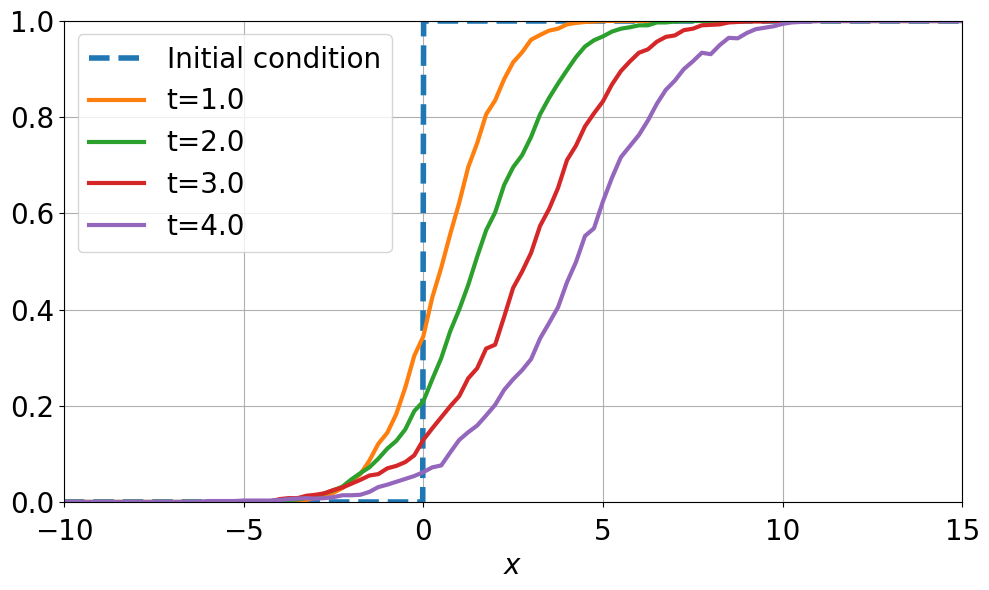

In [5]:
#Initial condition
x_ic=[a+i*(b-a)/(10*nx-1) for i in range(10*nx)]         #space discretization (it must be consistent with dimension d)
initial_condition = [f(x_ic[i],d) for i in range(10*nx)]

#Plots
#plt.figure(figsize=(10, 6))
#plt.plot(x, initial_condition, '--', label='Initial condition', linewidth=3)
#for i in range(nt):
#    plt.plot(x, y[i], '-', label=f"t={t[i]}", linewidth=3)
# plt.title(f"1D Time-Fractional F-KPP Equation "rf"$\alpha={alpha}$")
#plt.xlabel(r"$x$")
#plt.ylabel(r"$v(t,x)$")
#plt.ylim(-0.001,1.001)
#plt.legend()
#plt.grid(True, alpha=0.3)
#plt.savefig(f'front_a_{alpha}_gamma_{gamma}.png', format='png', dpi=150)
#plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_ic, initial_condition, '--', label='Initial condition', linewidth=4)
for i in range(nt):
    ax.plot(x, y[i], '-', label=f"t={t[i]}", linewidth=3)
ax.set_xlabel(r"$x$")
ax.margins(x=0)
ax.legend(loc="upper left", fontsize=20)
ax.set_ylim(-0.001, 1.001)
plt.tight_layout()
# ax.set_xticks(xx_arr)
ax.grid(True)
fig.savefig(f'front_a_{alpha}_gamma_{gamma}.pdf', bbox_inches="tight")